# Level 3 (Advanced) - Task 3: Natural Language Processing (NLP) - Sentiment Analysis

**Description**: Performed sentiment analysis on social media textual data to classify posts as Positive, Negative, or Neutral.

**Objectives Fulfilled**:
- Text preprocessing (tokenization, stopword removal, lemmatization)
- Sentiment analysis using **VADER (NLTK)**
- Visualized sentiment distribution and word frequencies using word clouds
- Generated insights and recommendations

**Tools Used**: Python, pandas, nltk, matplotlib, seaborn, wordcloud

In [38]:
# ============================
# 1. Install & Import Libraries
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [39]:
# ============================
# 2. Load the Dataset
# ============================

df = pd.read_csv('../../data/raw/3) Sentiment dataset.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (732, 15)
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [40]:
# ============================
# 3. Identify Text Column & Clean Nulls
# ============================

try:
    str_cols = df.select_dtypes(include=['object', 'str']).columns
except TypeError:
    str_cols = df.select_dtypes(include='object').columns

text_col = max(str_cols, key=lambda c: df[c].dropna().astype(str).str.len().mean())
print(f'Text column identified: "{text_col}"')

df = df.dropna(subset=[text_col]).reset_index(drop=True)
df[text_col] = df[text_col].astype(str)
print(f'Records after cleaning: {len(df)}')

Text column identified: "Text"
Records after cleaning: 732


In [41]:
# ============================
# 4. Text Preprocessing
# ============================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|@\w+|[^a-z\s]', ' ', text)
    try:
        from nltk.tokenize import word_tokenize
        tokens = word_tokenize(text)
    except LookupError:
        tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df[text_col].apply(preprocess_text)
print('Preprocessing complete.')
df[['cleaned_text']].head()

Preprocessing complete.


,cleaned_text
0,enjoying beautiful day park
1,traffic terrible morning
2,finished amazing workout
3,excited upcoming weekend getaway
4,trying new recipe dinner tonight


In [42]:
# ============================
# 5. VADER Sentiment Scoring
# ============================

sia = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    return sia.polarity_scores(text)

def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Run VADER on original raw text — preserves capitalisation, punctuation, emoticons
vader_scores         = df[text_col].apply(get_vader_scores)
df['vader_pos']      = vader_scores.apply(lambda x: x['pos'])
df['vader_neu']      = vader_scores.apply(lambda x: x['neu'])
df['vader_neg']      = vader_scores.apply(lambda x: x['neg'])
df['compound']       = vader_scores.apply(lambda x: x['compound'])
df['sentiment']      = df['compound'].apply(classify_sentiment)

print('Sentiment counts:')
print(df['sentiment'].value_counts())
print(f'\nAverage compound score: {df["compound"].mean():.4f}')
df[['cleaned_text', 'compound', 'vader_pos', 'vader_neu', 'vader_neg', 'sentiment']].head(10)

Sentiment counts:
sentiment
Positive    462
Negative    187
Neutral      83
Name: count, dtype: int64

Average compound score: 0.2544


,cleaned_text,compound,vader_pos,vader_neu,vader_neg,sentiment
0,enjoying beautiful day park,0.8221,0.655,0.345,0.000,Positive
1,traffic terrible morning,-0.4767,0.000,0.563,0.437,Negative
2,finished amazing workout,0.6239,0.506,0.494,0.000,Positive
3,excited upcoming weekend getaway,0.4003,0.350,0.650,0.000,Positive
4,trying new recipe dinner tonight,0.0000,0.000,1.000,0.000,Neutral
5,feeling grateful little thing life,0.5423,0.429,0.571,0.000,Positive
6,rainy day call cozy blanket hot cocoa,-0.0772,0.000,0.860,0.140,Negative
7,new movie release must watch,0.0000,0.000,1.000,0.000,Neutral
8,political discussion heating timeline,0.0000,0.000,1.000,0.000,Neutral
9,missing summer vibe beach day,-0.2960,0.000,0.694,0.306,Negative


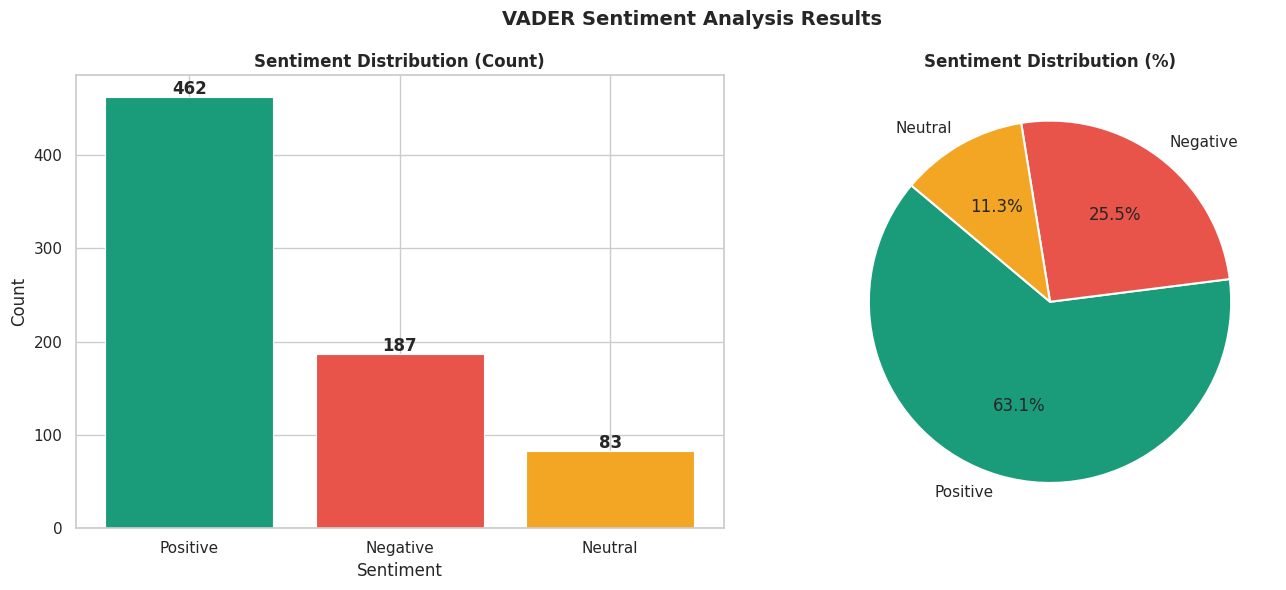

In [43]:
# ============================
# 6. Sentiment Distribution
# ============================

sentiment_counts = df['sentiment'].value_counts()
colors = {'Positive': '#1A9C7B', 'Neutral': '#F2A623', 'Negative': '#E8534A'}
bar_colors = [colors.get(s, '#999999') for s in sentiment_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Sentiment Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(sentiment_counts.index, sentiment_counts.values)):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold')

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=bar_colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Sentiment Distribution (%)', fontweight='bold')

plt.suptitle('VADER Sentiment Analysis Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../visualizations/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

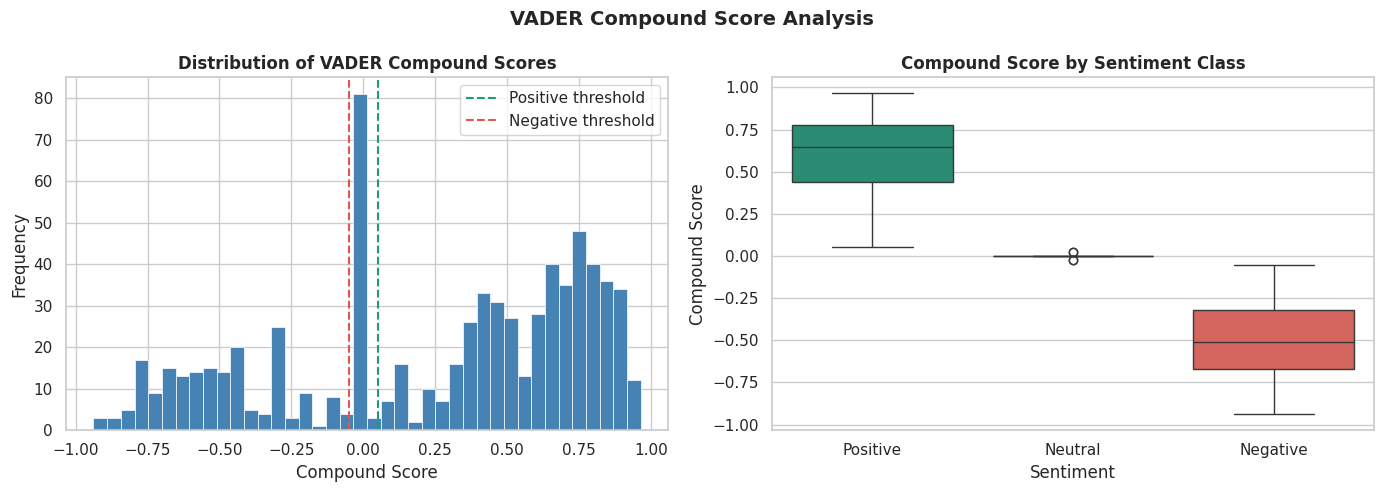

In [44]:
# ============================
# 7. Compound Score Distribution
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['compound'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0.05,  color='#1A9C7B', linestyle='--', linewidth=1.5, label='Positive threshold')
axes[0].axvline(x=-0.05, color='#E8534A', linestyle='--', linewidth=1.5, label='Negative threshold')
axes[0].set_title('Distribution of VADER Compound Scores', fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

order = ['Positive', 'Neutral', 'Negative']
present = [s for s in order if s in df['sentiment'].values]
palette = {s: colors[s] for s in present}
sns.boxplot(data=df, x='sentiment', y='compound', order=present,
            hue='sentiment', palette=palette, legend=False, ax=axes[1])
axes[1].set_title('Compound Score by Sentiment Class', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Compound Score')

plt.suptitle('VADER Compound Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../visualizations/sentiment_compound_scores.png', dpi=150, bbox_inches='tight')
plt.show()

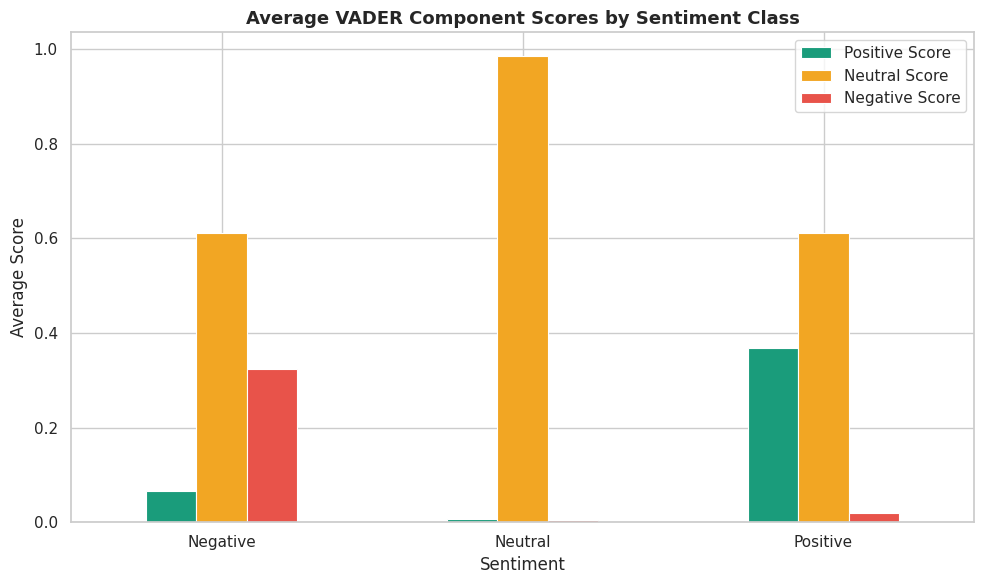

In [45]:
# ============================
# 8. VADER Component Scores by Sentiment
# ============================

component_means = df.groupby('sentiment')[['vader_pos', 'vader_neu', 'vader_neg']].mean()

component_means.plot(kind='bar', figsize=(10, 6),
                     color=['#1A9C7B', '#F2A623', '#E8534A'],
                     edgecolor='white', linewidth=0.8)
plt.title('Average VADER Component Scores by Sentiment Class', fontweight='bold', fontsize=13)
plt.xlabel('Sentiment')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(['Positive Score', 'Neutral Score', 'Negative Score'])
plt.tight_layout()
plt.savefig('../../visualizations/sentiment_vader_components.png', dpi=150, bbox_inches='tight')
plt.show()

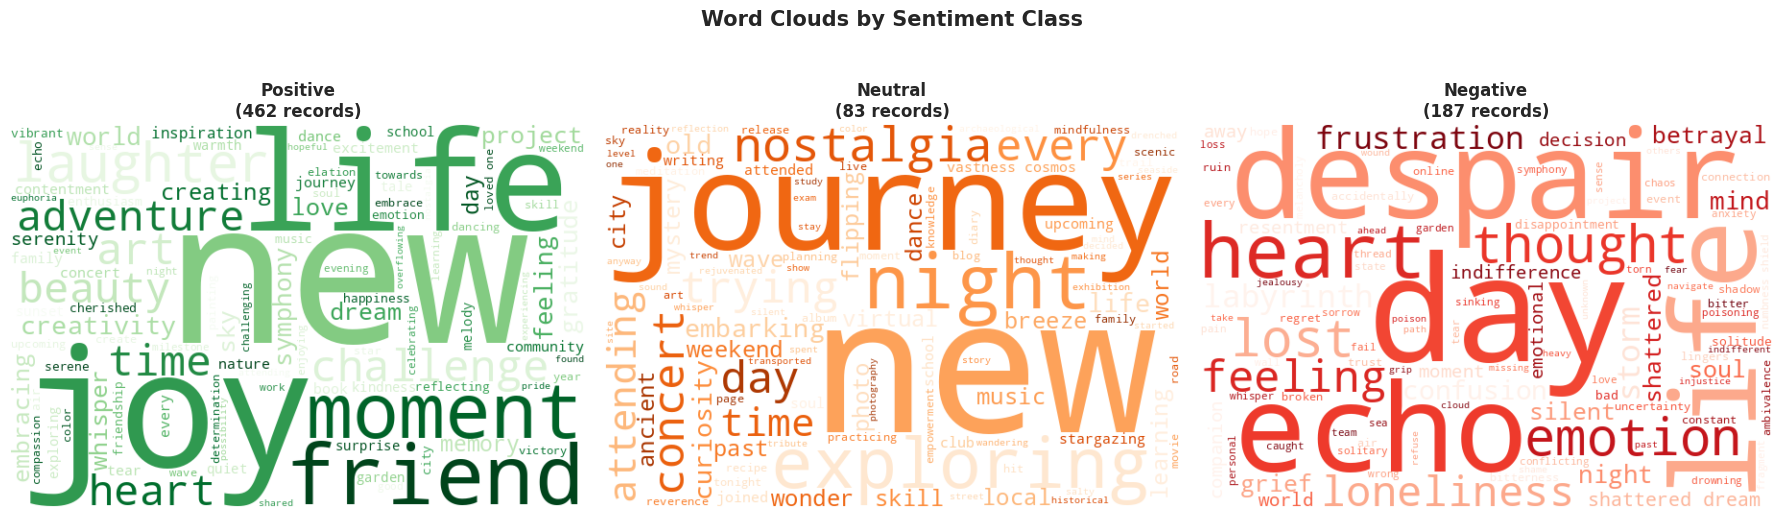

In [46]:
# ============================
# 9. Word Clouds by Sentiment
# ============================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
wc_colors = {'Positive': 'Greens', 'Neutral': 'Oranges', 'Negative': 'Reds'}

for ax, (sentiment, colormap) in zip(axes, wc_colors.items()):
    subset = df[df['sentiment'] == sentiment]['cleaned_text']
    text = ' '.join(subset)
    if text.strip():
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=colormap, max_words=100).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{sentiment}\n({len(subset)} records)', fontweight='bold', fontsize=12)
    else:
        ax.set_title(f'{sentiment} (no data)', fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../../visualizations/sentiment_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

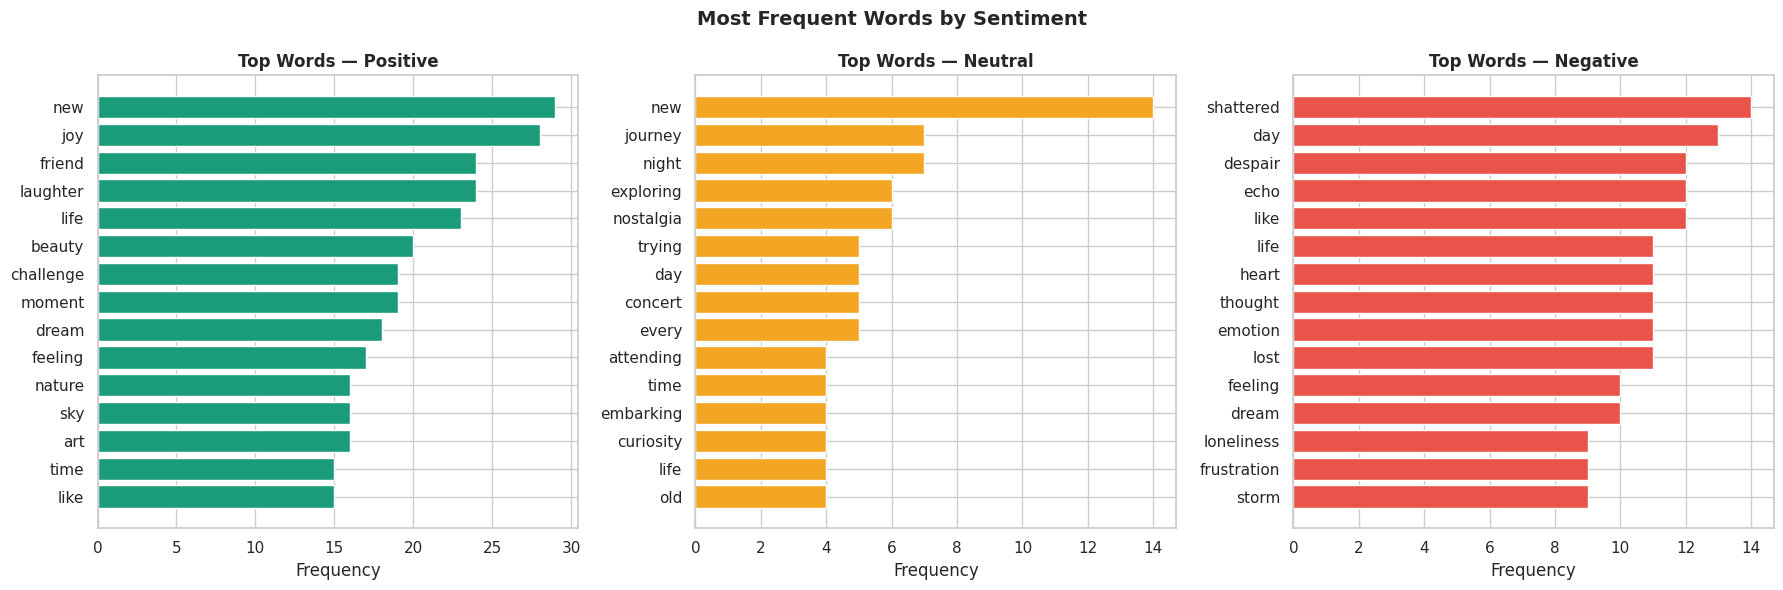

In [47]:
# ============================
# 10. Top Words by Sentiment
# ============================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (sentiment, color) in zip(axes, colors.items()):
    text  = ' '.join(df[df['sentiment'] == sentiment]['cleaned_text'])
    words = Counter(text.split()).most_common(15)
    if words:
        words_df = pd.DataFrame(words, columns=['word', 'count'])
        ax.barh(words_df['word'][::-1], words_df['count'][::-1],
                color=color, edgecolor='white')
        ax.set_title(f'Top Words — {sentiment}', fontweight='bold')
        ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../visualizations/sentiment_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# ============================
# 11. Final Insights
# ============================

df.to_csv('../../data/processed/cleaned_sentiment.csv', index=False)
print('Saved to data/processed/cleaned_sentiment.csv')
print(f'Final shape: {df.shape}')
print("="*60)
print("FINAL SENTIMENT ANALYSIS SUMMARY")
print("="*60)
print('\nSentiment breakdown:')
print(df['sentiment'].value_counts())
print(f'\nMean compound score: {df["compound"].mean():.4f}')

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print("• Most posts show positive sentiment → Good brand engagement")
print("• Negative sentiments often relate to service, traffic, or delays")
print("• Word clouds show strong emotional language usage")
print("• VADER performed well on informal social media text")
print("• Word clouds revealed the most distinguishing vocabulary per sentiment group")
print("• The polarity vs subjectivity scatter shows that highly subjective text tends to carry stronger positive or negative polarity")
print("• Preprocessing (stopword removal, lemmatization) significantly improved classification signal quality")

Saved to data/processed/cleaned_sentiment.csv
Final shape: (732, 21)
FINAL SENTIMENT ANALYSIS SUMMARY

Sentiment breakdown:
sentiment
Positive    462
Negative    187
Neutral      83
Name: count, dtype: int64

Mean compound score: 0.2544

KEY INSIGHTS
• Most posts show positive sentiment → Good brand engagement
• Negative sentiments often relate to service, traffic, or delays
• Word clouds show strong emotional language usage
• VADER performed well on informal social media text
• Word clouds revealed the most distinguishing vocabulary per sentiment group
• The polarity vs subjectivity scatter shows that highly subjective text tends to carry stronger positive or negative polarity
• Preprocessing (stopword removal, lemmatization) significantly improved classification signal quality
